In [1]:
#import relevant libraries
import os
#from scipy import stats

import numpy as np
#import scipy as sp
import pandas as pd
import NLProcessing
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import NLCLIMB
import NLMATH
import itertools
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap


import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

#NOTE: SUPPRESSES WARNINGS!

import warnings


warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)


Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 13.69it/s]


Numba compilation complete!


In [2]:
#initial file processing
workcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
officecomp = "C:\\Users\\Star\\"
homecomp = "D:"
filedir = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Climbing_New\\"
titledpath = homecomp
openPath = titledpath + filedir
files = os.listdir(openPath)

#identifying genotypes
responder = "ACR"
respondercsv = responder + ".csv"
wt = "w1118"


In [3]:
lstnew=[]


for file_no in os.listdir(openPath): 
    if respondercsv in file_no and "w1118" not in file_no :   #wt > acr files
        f = os.path.join(openPath, file_no)
        dfe=pd.read_csv(f)
        exptdf = dfe.drop(dfe.columns[[0]],axis = 1)
        driver = file_no.split(" ")[0]
        lstnew.append(driver)

## functions

In [4]:
#for fonts only
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_dirs = ["fonts"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

[f.name for f in matplotlib.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Fira Mono"

In [5]:
def multiresponder_osar(df2, responder):    
    from functools import reduce
    
    dfi=df2[(df2['light_intensity']=='Full')].reset_index(drop=True)  #Full light only
    dfi.replace([np.inf, -np.inf], np.nan, inplace=True)
    dfi.rename(columns={'driver': 'MBON'}, inplace = True)
    
    basegenotype = dfi['MBON'].unique()
    
    dfpi, sortedlist, dabestlist = chartplottingdabest_truncated(dfi, basegenotype, 'pi_smoothed_Pattern 01')
    dfspeed= chartplottingdabest_truncated(dfi, basegenotype, 'log2_speed_ratio_Pattern 01')[0]
    dfpace = chartplottingdabest_truncated(dfi, basegenotype, 'log2_pace_ratio_Pattern 01')[0]
    dflai = chartplottingdabest_truncated(dfi, basegenotype, 'light_attraction_index_Pattern 01')[0]

    piplot = dabest.load(dfpi, idx=dabestlist)
    spplot = dabest.load(dfspeed, idx=dabestlist)
    pcplot = dabest.load(dfpace, idx=dabestlist) 
    laiplot = dabest.load(dflai, idx=dabestlist)


    pitable = pd.DataFrame({'MBON': piplot.hedges_g.statistical_tests['test'],'Δ PI': piplot.hedges_g.statistical_tests['difference']})
    sptable = pd.DataFrame({'MBON': spplot.hedges_g.statistical_tests['test'],'Δ Log2 Speed Ratio': spplot.hedges_g.statistical_tests['difference']})
    pctable = pd.DataFrame({'MBON': pcplot.hedges_g.statistical_tests['test'],'Δ Log2 Pace Ratio': pcplot.hedges_g.statistical_tests['difference']})
    laitable = pd.DataFrame({'MBON': laiplot.hedges_g.statistical_tests['test'],'Δ LAI': laiplot.hedges_g.statistical_tests['difference']})

    tabletotallst = [pitable, sptable, pctable, laitable]

    tabletotal = reduce(lambda left, right: pd.merge(left, right, on =['MBON'], how = "outer"), tabletotallst)

    tabletotal['responder'] = responder
    
    return tabletotal

def chartplottingdabest_truncated(dfi, basegenotype, parameter):
    
    dfr1 = pd.DataFrame()
    for names in basegenotype:
        dfrr = pd.DataFrame()
        filter1 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Offspring')].copy().reset_index(drop=True)
        filter2 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Sibling')].copy().reset_index(drop=True)

        dfrr[names + " Cntrl" ] = filter2[parameter]
        dfrr[names] = filter1[parameter]
        dfr1 = pd.concat([dfr1, dfrr], axis = 1)
        
    l = dfr1.columns.tolist()
    titlelst = list(zip(l,l[1:]))[::2]  
    
    test = dabest.load(dfr1, idx=titlelst)    
    tab = pd.concat([test.hedges_g.results['test'], test.hedges_g.results['difference']], axis = 1)
    
    arrangedsorting = tab.sort_values(by=['difference'], ascending = True).reset_index(drop=True)

    newlist = []
    for n in arrangedsorting['test']:
        newlist.append((n +" Cntrl", n))

    return dfr1, arrangedsorting['test'], newlist

def twolightdabest(di, names, parameter, light):
    
    if light == 'Half' or light == 'Full':
        dfi = di[(di['light_intensity']==light)].reset_index(drop=True)
        dfrr = pd.DataFrame()
        filter1 = dfi[(dfi['status'] == 'Offspring')].reset_index(drop=True)
        filter2 = dfi[(dfi['status'] == 'Sibling')].reset_index(drop=True)
                
        dfrr[names + " Cntrl" ] = filter2[parameter]
        dfrr[names + " " + light] = filter1[parameter]
       
        l = dfrr.columns.tolist()
        titlelst = list(zip(l,l[1:]))[::2]  
        test = dabest.load(dfrr, idx=titlelst)    
        
    if light == 'Both':
        
        df_half = di[(di['light_intensity']=="Half")].reset_index(drop=True)
        dfrr = pd.DataFrame()
        filter1_half = df_half[(df_half['status'] == 'Offspring')].reset_index(drop=True)
        filter2_half = df_half[(df_half['status'] == 'Sibling')].reset_index(drop=True)
        
        df_full = di[(di['light_intensity']=="Full")].reset_index(drop=True)
        filter1_full = df_full[(df_full['status'] == 'Offspring')].reset_index(drop=True)
        filter2_full = df_full[(df_full['status'] == 'Sibling')].reset_index(drop=True)
                
        dfrr["Cntrl_Half"] = filter2_half[parameter]
        dfrr[ "Half"] = filter1_half[parameter]
        dfrr["Cntrl_Full" ] = filter2_full[parameter]
        dfrr["Full"] = filter1_full[parameter]
        l = dfrr.columns.tolist()
        titlelst = list(zip(l,l[1:]))[::2]  
        test = dabest.load(dfrr, idx=titlelst)    
    
    return test

import textwrap


## Code - Climbing

In [6]:
newfile2 = openPath + "Compilation with delta\\2025deltagcollection\\"
files2 = os.listdir(newfile2)
totalfile = pd.DataFrame()

for n in files2:
    
    openfile = pd.read_csv(newfile2 + n)
    nameofmbon = n.split(" ")[0] 
    openfile['responder'] = n.split(" x ")[1].split("_")[0]
    totalfile = pd.concat([totalfile, openfile], axis = 0).reset_index(drop=True)

lstofallvariables = []
for n in totalfile.columns.to_list()[1:-1]:
    lstofallvariables.append(n.split("_")[0])
lstnamings= list(set(lstofallvariables))

totalfile['genotypeandresponder'] = totalfile["MBON"] + "_" + totalfile['responder']   #has bootstraps

#only delta-g
onlymeans = totalfile.loc[:, ~totalfile.columns.str.endswith('_bootstrap')].drop_duplicates().reset_index(drop=True)

mbononly=onlymeans[~onlymeans['MBON'].isin(['R58', 'Th-Gal4'])]

# specificmetrics = ['MBON', 'bspeed_deltag', 'speed_deltag', 'fallprop_deltag', 'fallnumber_deltag',  'height_deltag', 'maxvelocity_deltag', 'straightindex_deltag', 'pause_deltag', 'meanpause_deltag',
#                    'responder', 'genotypeandresponder']

# eightmetrics = pd.DataFrame()
# for p in specificmetrics:
#     eightmetrics = pd.concat([eightmetrics, mbononly[p]], axis =1) 
# eightmetrics = eightmetrics.reset_index(drop=True)


In [7]:
#lobe location

files2 = os.listdir(newfile2)

MBONList = []
for yy in files2:
    MBONList.append(yy.split(" ")[0])

MBONList = list(set(MBONList))

#reading mbonlist file
directorynew = os.path.dirname(os.path.dirname(openPath)) #goes up one directory
fileinnewdirc = os.listdir(directorynew)

for file_no2 in fileinnewdirc:
    if ".csv" in file_no2:
        ff = os.path.join(directorynew, file_no2)
        csvfile = pd.read_csv(ff)

csvfile = csvfile.astype('string')

for n, k in zip(["B", "y", "a"], ['β', "γ", "α"]):
    csvfile['Lobe'] = csvfile['Lobe'].str.replace(n, k)

lobelocation = NLProcessing.generate_lobelocation(MBONList, "MBONlist.csv")

In [8]:
#mini list of only SPECIFIC responder
dfoneresponder = mbononly.copy()

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon = dfoneresponder[dfoneresponder['responder']=="Chrimson2"].sort_values(by = "bspeed_deltag", ascending=True).reset_index(drop=True)
    colormap = 'RdGy'

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon = dfoneresponder[dfoneresponder['responder']=="ACR"].sort_values(by = "bspeed_deltag", ascending=True).reset_index(drop=True)
    colormap = 'BrBG'

df_specificmbon.columns = df_specificmbon.columns.str.replace('_deltag', '')
df60 = df_specificmbon.copy()
df60 = df60.set_index(['MBON']).drop(['responder'], axis =1)

#adding extra axes label
lobloclst = []
mbonloclst = []
df_singleresponder_lobeloc = df_specificmbon.copy()

for n in df_specificmbon['MBON']:    
    lobloclst.append(lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0])
    mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
df_singleresponder_lobeloc['Lobe'] = lobloclst
df_singleresponder_lobeloc['Name'] = mbonloclst

# Sort by MBON numbers instead of bspeed_deltag
df_singleresponder_lobeloc = df_singleresponder_lobeloc.sort_values(by = "Name", ascending=True).reset_index(drop=True)

# Separate data for two subplots
# Subplot 1: Only fallnumber (Delta-delta)
df60_fallnumber = df_singleresponder_lobeloc.set_index('MBON')[['fallnumber']].copy()

# Subplot 2: All other columns (Delta-g) 
df60_other = df_singleresponder_lobeloc.set_index('MBON').drop(['responder', 'Name', 'Lobe', 'genotypeandresponder', 'fallnumber'], axis = 1).copy()

# Create figure with 2 subplots
fig1, (ax4_left, ax4_right) = plt.subplots(1, 2, figsize=(10, 18), gridspec_kw={'width_ratios': [1, 4]})

newdf_singleresponder_lobeloc = pd.DataFrame()
naming = df_singleresponder_lobeloc['Name'].to_frame().rename(columns = {"Name": ""})
lobing = df_singleresponder_lobeloc['Lobe'].to_frame().rename(columns = {"Lobe": ""})
newlabel =(naming.values + "\n " + lobing.values).tolist()
newdf_singleresponder_lobeloc['Merge'] = newlabel

# Labels for subplot 1 (fallnumber)
xticklabel_fallnumber = ['# falls']

# Labels for subplot 2 (other columns)
xticklabeldf_other = df60_other.rename(columns={'speed': 'Speed', 'bspeed': 'Bout speed', 'pausepos': 'Pause position', 'bout': '# Bouts', 'meanbout': "Mean bout time",
                      'straightindex': 'Straightness Index', 'height': 'Max height climbed', 'maxvelocity': 'Max velocity'})
xticklabellist_other = xticklabeldf_other.columns.tolist()

#colorbar for subplot 2
cax2 = inset_axes(ax4_right,
                 width="15%",  # width: 40% of parent_bbox width
                 height="0.8%",  # height: 10% of parent_bbox height
                 loc='lower right',
                 bbox_to_anchor=(0.12, 1.05, 1, 1),
                 bbox_transform=ax4_right.transAxes,
                 borderpad=-2,
                 )

sns.set_style("whitegrid", {'axes.grid' : False})    

# Subplot 1: fallnumber (Delta-delta) - now with MBON names as y-labels       
j7_left = sns.heatmap(df60_fallnumber, ax = ax4_left, annot=True, fmt=".1f", vmin = -1.5, vmax = 1.5, cmap=colormap, annot_kws={"size": 10, }, linewidths=0.0, edgecolor = "none",  xticklabels=xticklabel_fallnumber, yticklabels=True,
                 clip_on=False, cbar = False)

# Subplot 2: other columns (Delta-g) - no y-labels on left side
j7_right = sns.heatmap(df60_other, ax = ax4_right, annot=True, fmt=".1f", vmin = -1.5, vmax = 1.5, cmap=colormap, linewidths=0.0, edgecolor = "none",  xticklabels=xticklabellist_other, yticklabels=True,
                 clip_on=False, cbar_ax=cax2, cbar_kws = dict(orientation = "horizontal", ticks = [-1.5,0,1.5]), annot_kws={"size": 10, })

# colorbar changes
cbar = j7_right.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)

# For more detailed control (optional):
for label in cbar.ax.get_xticklabels():  # Note: use get_xticklabels() for horizontal colorbar
    # label.set_fontsize(10)
    label.set_family('Fira Mono')

    
# Format subplot 1
j7_left.set_ylabel('')
#j7_left.set_yticklabels(j7_left.get_yticklabels(), va='center', rotation = 0, fontsize = 13)
j7_left.set_xticklabels(j7_left.get_xticklabels(), fontsize = 8)
j7_left.set_title('ΔΔ', weight='bold', fontsize = 14)

# Format subplot 2
j7_right.set_ylabel('')
j7_right.set_yticklabels([], visible = False)
j7_right.set_xticklabels(j7_right.get_xticklabels(), fontsize = 8)
NLProcessing.wrap_labels(j7_right, 5)
j7_right.set_title('Δg', weight='bold', fontsize = 14)
j7_right.tick_params(axis='both', which='both', length=0)

# Drawing the frame for subplot 1
j7_left.axhline(y = 0, color = 'k', linewidth = 5) 
j7_left.axhline(y = len(df60_fallnumber), color = 'k', linewidth = 5) 
j7_left.axvline(x = 0, color = 'k', linewidth = 5) 
j7_left.axvline(x = 1, color = 'k', linewidth = 5) 

# Drawing the frame for subplot 2
j7_right.axhline(y = 0, color = 'k', linewidth = 5) 
j7_right.axhline(y = len(df60_other), color = 'k', linewidth = 5) 
j7_right.axvline(x = 0, color = 'k', linewidth = 5) 
j7_right.axvline(x = len(df60_other.columns), color = 'k', linewidth = 5) 

#secondary axes for subplot 2 - MBON lobe and naming labels on right side
j8_right = j7_right.twinx()
j8_right.set_ylim([0,j7_right.get_ylim()[0]])
j8_right.set_yticks(j7_right.get_yticks())

#y labels for mbon lobes and naming on subplot 2 (right side)
labellinglist = newdf_singleresponder_lobeloc['Merge'].iloc[::-1]
labelledlist = []
for n in labellinglist:
    labelledlist.extend(n)
j8_right.set_yticklabels(labelledlist, fontsize=9)
j8_right.spines['top'].set_visible(False)
j8_right.spines['right'].set_visible(False)
j8_right.spines['bottom'].set_visible(False)
j8_right.spines['left'].set_visible(False)

# Overall title
fig1.suptitle('Plot of MBONs > ' + responderrename +' and their effects \n across locomotor reactivity parameters for Climbing Assay', x=0.5, y=1.0, weight='bold', fontsize =16)
plt.rcParams["font.family"] = "Fira Mono"
fig1.tight_layout()

# plt.savefig(openPath + "images\\" + date + "_" + responder + "_deltagheatmapwithlobelocations.png", dpi = 1200)
# plt.savefig(openPath + "images\\" + date + "_" + responder + "_deltagheatmapwithlobelocations.svg")

KeyError: "None of [Index(['fallnumber'], dtype='object')] are in the [columns]"

## Code - OSAR

In [ ]:
#lobe location

newfile2 = titledpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Climbing_New\\Compilation with delta\\2025deltagcollection\\"
files2 = os.listdir(newfile2)

MBONList = []
for yy in files2:
    MBONList.append(yy.split(" ")[0])

MBONList = list(set(MBONList))

lobelocation = NLProcessing.generate_lobelocation(MBONList, "MBONlist.csv")

In [ ]:
from collections import Counter
counts = Counter([item.split(' ')[0] for item in files2])
matchingsets = [value for value, count in counts.items() if count > 1]
matchinglst = [v for v in files2 if any(short_name in v for short_name in matchingsets)]
dfreg_ACR = pd.DataFrame()
dfreg_Chrimson2 = pd.DataFrame()

for f in matchinglst:
    if "Chrimson2" in f:
        temp = pd.read_csv(newfile2 + f, index_col=0)
        temp = temp.loc[:, ~temp.columns.str.endswith('_bootstrap')].drop_duplicates()
        dfreg_Chrimson2 = pd.concat([dfreg_Chrimson2, temp], axis = 0)
    if "ACR" in f:
        temp = pd.read_csv(newfile2 + f, index_col=0)
        temp = temp.loc[:, ~temp.columns.str.endswith('_bootstrap')].drop_duplicates()
        dfreg_ACR = pd.concat([dfreg_ACR, temp], axis = 0)
        

dfreg_Chrimson2 = dfreg_Chrimson2.reset_index(drop=False)
dfreg_Chrimson2['genotypeandresponder'] = dfreg_Chrimson2['MBON'] + '_Chrimson2'

dfreg_ACR = dfreg_ACR.reset_index(drop=False)
dfreg_ACR['genotypeandresponder'] = dfreg_ACR['MBON'] + '_ACR'

In [ ]:
root = titledpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\"
filepathACR = root + "20250523_ACR_totalcompilation.csv"
filepathCR2 = root + "20250523_Chrimson2_totalcompilation.csv"

dffileACR= pd.read_csv(filepathACR, index_col=0)
dffileCR2= pd.read_csv(filepathCR2, index_col=0)

dffACR = multiresponder_osar(dffileACR, "ACR")
dffCR2 = multiresponder_osar(dffileCR2, "Chrimson2")


dfmultiresponderosar = pd.concat([dffACR, dffCR2]).reset_index(drop=True)
dfmultiresponderosar['genotypeandresponder'] = dfmultiresponderosar['MBON'] + "_" + dfmultiresponderosar['responder']

In [ ]:
PCAdf_ACR = dfmultiresponderosar[dfmultiresponderosar['responder'] == "ACR"].iloc[:,0:5].set_index('MBON')
PCAdf_Chrimson2 = dfmultiresponderosar[dfmultiresponderosar['responder'] == "Chrimson2"].iloc[:,0:5].set_index('MBON')

## Direct comparison for speed ratios

In [ ]:
newfile2 = openPath + "Compilation with delta\\2025climbingtoosarcomp\\"
files2 = os.listdir(newfile2)
totalfile = pd.DataFrame()

for n in files2:
    
    openfile = pd.read_csv(newfile2 + n)
    nameofmbon = n.split(" ")[0] 
    openfile['responder'] = n.split(" x ")[1].split("_")[0]
    totalfile = pd.concat([totalfile, openfile], axis = 0).reset_index(drop=True)

lstofallvariables = []
for n in totalfile.columns.to_list()[1:-1]:
    lstofallvariables.append(n.split("_")[0])
lstnamings= list(set(lstofallvariables))

totalfile['genotypeandresponder'] = totalfile["MBON"] + "_" + totalfile['responder']   #has bootstraps

#only delta-g
onlymeans = totalfile.loc[:, ~totalfile.columns.str.endswith('_bootstrap')].drop_duplicates().reset_index(drop=True)

mbononly=onlymeans[~onlymeans['MBON'].isin(['R58', 'Th-Gal4'])]

# specificmetrics = ['MBON', 'bspeed_deltag', 'speed_deltag', 'fallprop_deltag', 'fallnumber_deltag',  'height_deltag', 'maxvelocity_deltag', 'straightindex_deltag', 'pause_deltag', 'meanpause_deltag',
#                    'responder', 'genotypeandresponder']

# eightmetrics = pd.DataFrame()
# for p in specificmetrics:
#     eightmetrics = pd.concat([eightmetrics, mbononly[p]], axis =1) 
# eightmetrics = eightmetrics.reset_index(drop=True)


In [ ]:
#lobe location

files2 = os.listdir(newfile2)

MBONList = []
for yy in files2:
    MBONList.append(yy.split(" ")[0])

MBONList = list(set(MBONList))

#reading mbonlist file
directorynew = os.path.dirname(os.path.dirname(openPath)) #goes up one directory
fileinnewdirc = os.listdir(directorynew)

for file_no2 in fileinnewdirc:
    if ".csv" in file_no2:
        ff = os.path.join(directorynew, file_no2)
        csvfile = pd.read_csv(ff)

csvfile = csvfile.astype('string')

for n, k in zip(["B", "y", "a"], ['β', "γ", "α"]):
    csvfile['Lobe'] = csvfile['Lobe'].str.replace(n, k)

lobelocation = NLProcessing.generate_lobelocation(MBONList, "MBONlist.csv")

In [ ]:
#mini list of only SPECIFIC responder
dfoneresponder = mbononly.copy()

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon = dfoneresponder[dfoneresponder['responder']=="Chrimson2"].sort_values(by = "bspeed_deltag", ascending=True).reset_index(drop=True)
    colormap = 'RdGy'

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon = dfoneresponder[dfoneresponder['responder']=="ACR"].sort_values(by = "bspeed_deltag", ascending=True).reset_index(drop=True)
    colormap = 'BrBG'

df_specificmbon.columns = df_specificmbon.columns.str.replace('_deltag', '')
df60 = df_specificmbon.copy()
df60 = df60.set_index(['MBON']).drop(['responder'], axis =1)

#adding extra axes label
lobloclst = []
mbonloclst = []
df_singleresponder_lobeloc = df_specificmbon.copy()

for n in df_specificmbon['MBON']:    
    lobloclst.append(lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0])
    mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
df_singleresponder_lobeloc['Lobe'] = lobloclst
df_singleresponder_lobeloc['Name'] = mbonloclst

# Sort by MBON numbers instead of bspeed_deltag
df_singleresponder_lobeloc = df_singleresponder_lobeloc.sort_values(by = "Name", ascending=True).reset_index(drop=True)

# Separate data for two subplots
# Subplot 1: Only fallnumber (Delta-delta)
df60_fallnumber = df_singleresponder_lobeloc.set_index('MBON')[['fallnumber']].copy()

# Subplot 2: All other columns (Delta-g) 
df60_other = df_singleresponder_lobeloc.set_index('MBON').drop(['responder', 'Name', 'Lobe', 'genotypeandresponder', 'fallnumber'], axis = 1).copy()

# Create figure with 2 subplots
fig1, (ax4_left, ax4_right) = plt.subplots(1, 2, figsize=(10, 18), gridspec_kw={'width_ratios': [1, 4]})

newdf_singleresponder_lobeloc = pd.DataFrame()
naming = df_singleresponder_lobeloc['Name'].to_frame().rename(columns = {"Name": ""})
lobing = df_singleresponder_lobeloc['Lobe'].to_frame().rename(columns = {"Lobe": ""})
newlabel =(naming.values + "\n " + lobing.values).tolist()
newdf_singleresponder_lobeloc['Merge'] = newlabel

# Labels for subplot 1 (fallnumber)
xticklabel_fallnumber = ['# falls']

# Labels for subplot 2 (other columns)
xticklabeldf_other = df60_other.rename(columns={'speed': 'Speed', 'bspeed': 'Bout speed', 'pausepos': 'Pause position', 'bout': '# Bouts', 'meanbout': "Mean bout time",
                      'straightindex': 'Straightness Index', 'height': 'Max height climbed', 'maxvelocity': 'Max velocity'})
xticklabellist_other = xticklabeldf_other.columns.tolist()

#colorbar for subplot 2
cax2 = inset_axes(ax4_right,
                 width="15%",  # width: 40% of parent_bbox width
                 height="0.8%",  # height: 10% of parent_bbox height
                 loc='lower right',
                 bbox_to_anchor=(0.12, 1.05, 1, 1),
                 bbox_transform=ax4_right.transAxes,
                 borderpad=-2,
                 )

sns.set_style("whitegrid", {'axes.grid' : False})    

# Subplot 1: fallnumber (Delta-delta) - now with MBON names as y-labels       
j7_left = sns.heatmap(df60_fallnumber, ax = ax4_left, annot=True, fmt=".1f", vmin = -1.5, vmax = 1.5, cmap=colormap, annot_kws={"size": 10, }, linewidths=0.0, edgecolor = "none",  xticklabels=xticklabel_fallnumber, yticklabels=True,
                 clip_on=False, cbar = False)

# Subplot 2: other columns (Delta-g) - no y-labels on left side
j7_right = sns.heatmap(df60_other, ax = ax4_right, annot=True, fmt=".1f", vmin = -1.5, vmax = 1.5, cmap=colormap, linewidths=0.0, edgecolor = "none",  xticklabels=xticklabellist_other, yticklabels=True,
                 clip_on=False, cbar_ax=cax2, cbar_kws = dict(orientation = "horizontal", ticks = [-1.5,0,1.5]), annot_kws={"size": 10, })

# colorbar changes
cbar = j7_right.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)

# For more detailed control (optional):
for label in cbar.ax.get_xticklabels():  # Note: use get_xticklabels() for horizontal colorbar
    # label.set_fontsize(10)
    label.set_family('Fira Mono')

    
# Format subplot 1
j7_left.set_ylabel('')
#j7_left.set_yticklabels(j7_left.get_yticklabels(), va='center', rotation = 0, fontsize = 13)
j7_left.set_xticklabels(j7_left.get_xticklabels(), fontsize = 8)
j7_left.set_title('ΔΔ', weight='bold', fontsize = 14)

# Format subplot 2
j7_right.set_ylabel('')
j7_right.set_yticklabels([], visible = False)
j7_right.set_xticklabels(j7_right.get_xticklabels(), fontsize = 8)
NLProcessing.wrap_labels(j7_right, 5)
j7_right.set_title('Δg', weight='bold', fontsize = 14)
j7_right.tick_params(axis='both', which='both', length=0)

# Drawing the frame for subplot 1
j7_left.axhline(y = 0, color = 'k', linewidth = 5) 
j7_left.axhline(y = len(df60_fallnumber), color = 'k', linewidth = 5) 
j7_left.axvline(x = 0, color = 'k', linewidth = 5) 
j7_left.axvline(x = 1, color = 'k', linewidth = 5) 

# Drawing the frame for subplot 2
j7_right.axhline(y = 0, color = 'k', linewidth = 5) 
j7_right.axhline(y = len(df60_other), color = 'k', linewidth = 5) 
j7_right.axvline(x = 0, color = 'k', linewidth = 5) 
j7_right.axvline(x = len(df60_other.columns), color = 'k', linewidth = 5) 

#secondary axes for subplot 2 - MBON lobe and naming labels on right side
j8_right = j7_right.twinx()
j8_right.set_ylim([0,j7_right.get_ylim()[0]])
j8_right.set_yticks(j7_right.get_yticks())

#y labels for mbon lobes and naming on subplot 2 (right side)
labellinglist = newdf_singleresponder_lobeloc['Merge'].iloc[::-1]
labelledlist = []
for n in labellinglist:
    labelledlist.extend(n)
j8_right.set_yticklabels(labelledlist, fontsize=9)
j8_right.spines['top'].set_visible(False)
j8_right.spines['right'].set_visible(False)
j8_right.spines['bottom'].set_visible(False)
j8_right.spines['left'].set_visible(False)

# Overall title
fig1.suptitle('Plot of MBONs > ' + responderrename +' and their effects \n across locomotor reactivity parameters for Climbing Assay', x=0.5, y=1.0, weight='bold', fontsize =16)
plt.rcParams["font.family"] = "Fira Mono"
fig1.tight_layout()

# plt.savefig(openPath + "images\\" + date + "_" + responder + "_deltagheatmapwithlobelocations.png", dpi = 1200)
# plt.savefig(openPath + "images\\" + date + "_" + responder + "_deltagheatmapwithlobelocations.svg")

## PCA

In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --------------------------------------
# 2. Run PCA
# --------------------------------------
pca = PCA()
X_pca = pca.fit_transform(PCAdf)

# --------------------------------------
# 3. Analyze Parameter Contributions
# --------------------------------------
# Create a loadings matrix (how each parameter contributes to PCs)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Create a DataFrame for easy interpretation
loadings_df = pd.DataFrame(
    loadings,
    columns=[f'PC{i+1}' for i in range(4)],
    index=['PI', 'LAI', 'SpeedRatio', 'PaceRatio']
)
print("\nParameter contributions to PCs (loadings):")
print(loadings_df)


Parameter contributions to PCs (loadings):
                 PC1       PC2       PC3       PC4
PI         -0.365129  0.153212 -0.058632  0.109491
LAI         0.451057  0.138562  0.156895  0.069784
SpeedRatio -0.215389 -0.205669  0.274440  0.031029
PaceRatio  -0.196192  0.259215  0.168537 -0.077399


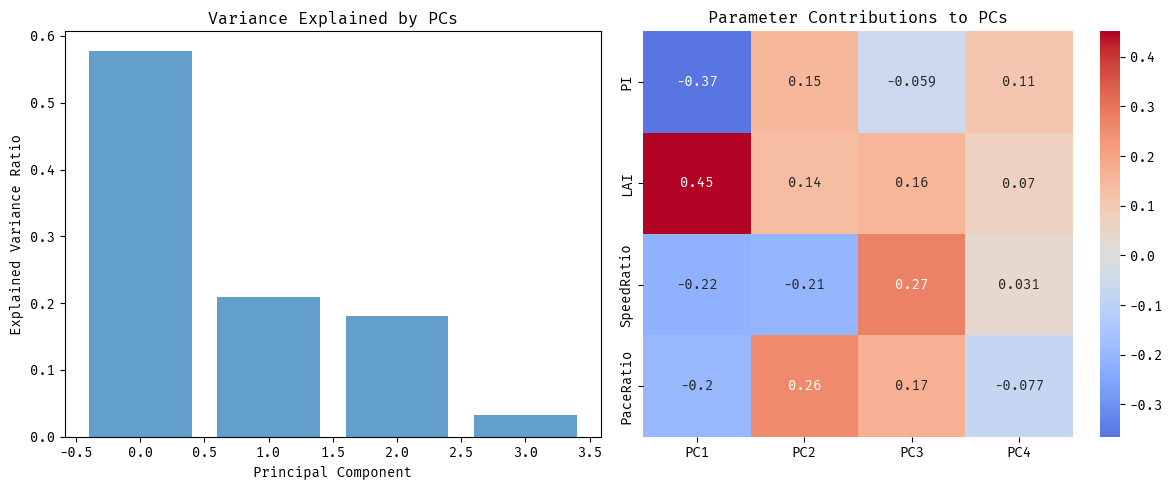

In [12]:
# --------------------------------------
# 4. Visualization
# --------------------------------------
plt.figure(figsize=(12, 5))

# Plot explained variance
plt.subplot(1, 2, 1)
plt.bar(range(4), pca.explained_variance_ratio_, alpha=0.7)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Variance Explained by PCs')

# Plot PC loadings (heatmap)
plt.subplot(1, 2, 2)
sns.heatmap(loadings_df, annot=True, cmap='coolwarm', center=0)
plt.title('Parameter Contributions to PCs')
plt.tight_layout()
plt.show()



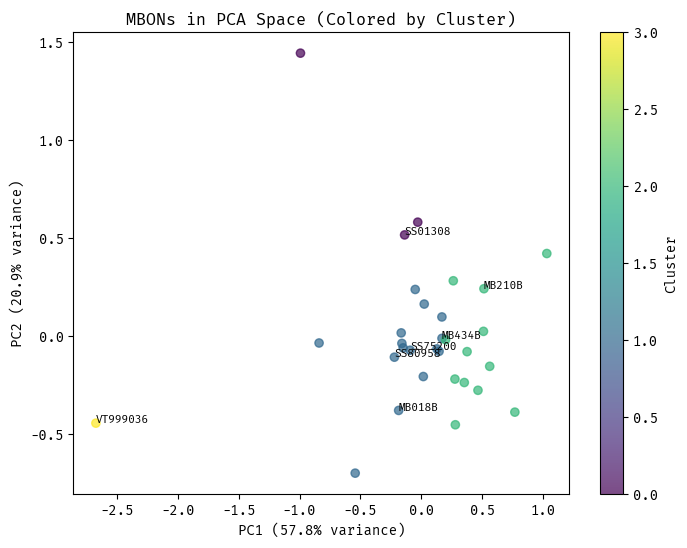

In [13]:
# --------------------------------------
# 5. Optional: 2D Projection with Clusters
# --------------------------------------
# Example with k-means clustering
from sklearn.cluster import KMeans

# Cluster in PCA space (using first 2 PCs)
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_pca[:, :2])

# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')

# Annotate some points (avoid overcrowding)
for i, name in enumerate(PCAdf.index):
    if i % 5 == 0:  # Label every 5th MBON
        plt.annotate(name, (X_pca[i, 0], X_pca[i, 1]), fontsize=8)

plt.colorbar(scatter, label='Cluster')
plt.title('MBONs in PCA Space (Colored by Cluster)')
plt.show()

## Paired plot

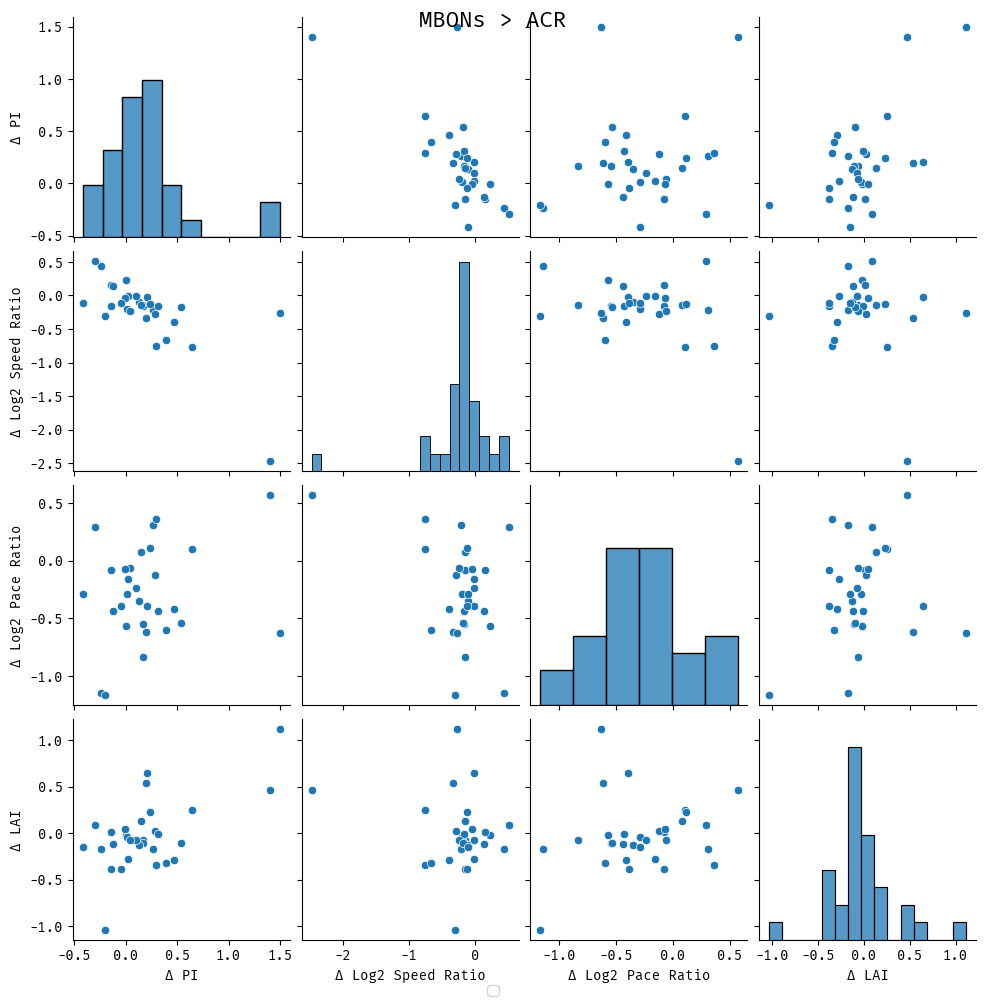

In [17]:
t1 = sns.pairplot(data=PCAdf, corner =False)
t1.fig.suptitle('MBONs > ' + responder, weight='bold', fontsize =16, y = 0.99 )

handles = t1._legend_data.values()
labels = t1._legend_data.keys()
t1.fig.legend(handles=handles, labels=labels, loc='lower center', ncol=5)


#plt.savefig(openPath + "images\\" + date + "_" + responder + "_separationbyNTtypes_" + secondrule +".png", dpi = 1200, bbox_inches='tight')

## line regression

In [19]:
def omission(df):
    respon = '_' + df['responder'].unique()[0]
    tempdff = df[~df['MBON'].isin(['R76B09', 'VT999036'])].reset_index(drop=True) #removing outlier
    dfomitted = tempdff[~((tempdff['Δ PI'].abs() < 0.0) & (tempdff['Δ Log2 Pace Ratio'].abs() < 0.0))]
    dfomitted = dfomitted.rename(columns={col: col + respon for col in dfomitted.columns[1:4]})
    
    return dfomitted.reset_index(drop=True)

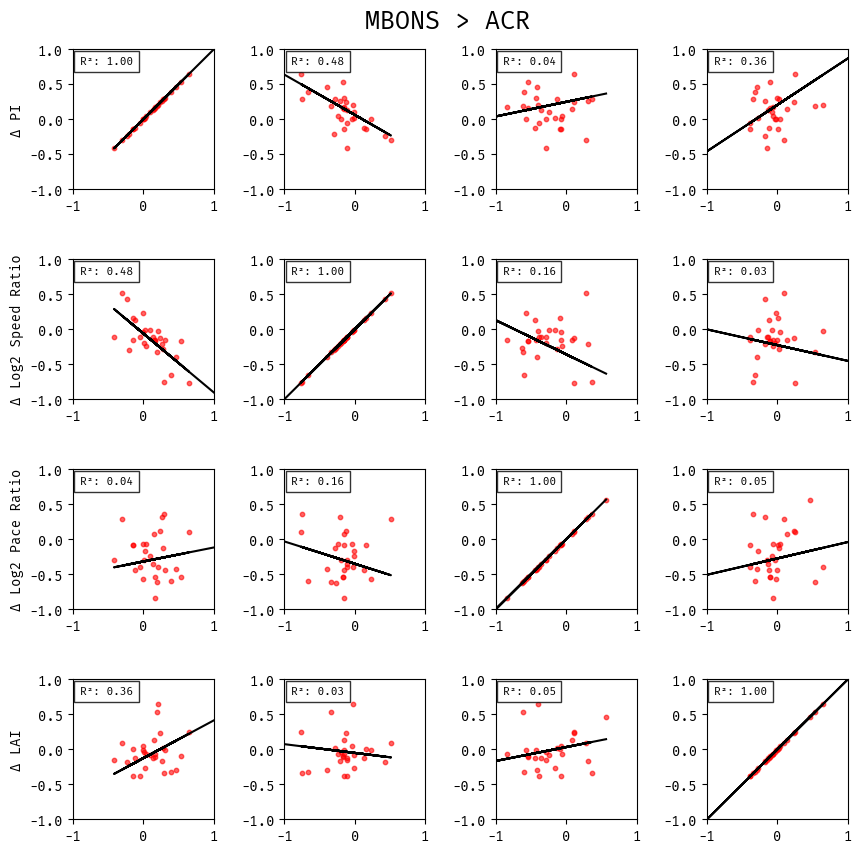

In [25]:
# Create a figure and axis grid
from scipy.stats import linregress, pearsonr, t

fig, axes = plt.subplots(4, 4, figsize=(10, 10), gridspec_kw={'wspace': 0.5, 'hspace': 0.5})

df_linreg = PCAdf

# Plot scatter plots for every combination of metrics
for i in range(len(df_linreg.columns)):
    for j in range(len(df_linreg.columns)):
        ax = axes[i, j]
        x = df_linreg.iloc[:, j]
        y = df_linreg.iloc[:, i]
        ax.scatter(x, y, alpha=0.6, c = "r", s=10)  # Scatter plot
        
        # Perform linear regression
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        
        # Add line of best fit
        ax.plot(x, slope * x + intercept, color='black')  # Regression line
        
        # Annotate with R² value
        ax.text(0.05, 0.95, f"R²: {r_value**2:.2f}", 
                transform=ax.transAxes, fontsize=8, verticalalignment='top', 
                bbox=dict(facecolor='white', alpha=0.8))
        
        # Set axis labels
        if i == 8:  # Add x-axis labels only for the bottom row
            ax.set_xlabel(df_linreg.columns[j])
        if j == 0:  # Add y-axis labels only for the first column
            ax.set_ylabel(df_linreg.columns[i])

        ax.set_xlim([-1, 1])
        ax.set_ylim([-1, 1])
# Remove empty space between subplots
plt.tight_layout()

fig.suptitle("MBONS > " + responder, fontsize = 18, y = 0.92)

# Show the plot
plt.show()

## clustering

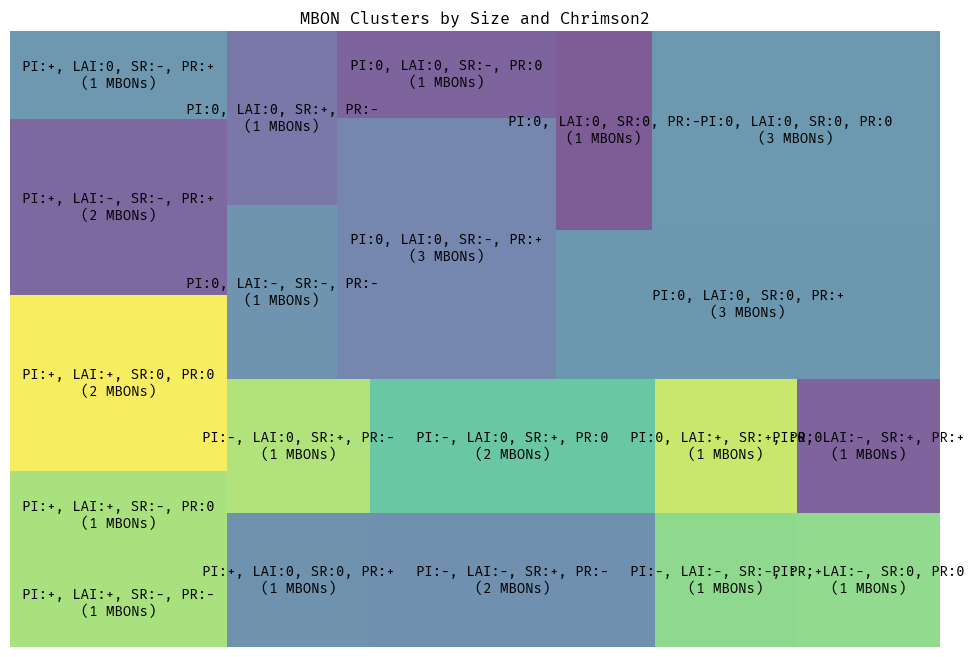

In [14]:
# Define thresholding function with descriptive labels
import squarify

clusteringdf = PCAdf_Chrimson2.reset_index()
responder = 'Chrimson2'
clusteringdf = clusteringdf[~clusteringdf['MBON'].isin(['R58', 'Th-Gal4', 'R76B09'])]
def categorize(value, metric_name):
    if value >= 0.2:
        return f"{metric_name}:+"  # Positive
    elif value <= -0.2:
        return f"{metric_name}:-"  # Negative
    else:
        return f"{metric_name}:0"  # Neutral

# Apply categorization with metric abbreviations
clusteringdf['Cluster'] = (
    clusteringdf['Δ PI'].apply(lambda x: categorize(x, "PI")) + ", " +
    clusteringdf['Δ LAI'].apply(lambda x: categorize(x, "LAI")) + ", " +
    clusteringdf['Δ Log2 Speed Ratio'].apply(lambda x: categorize(x, "SR")) + ", " +
    clusteringdf['Δ Log2 Pace Ratio'].apply(lambda x: categorize(x, "PR"))
)

# Group MBONs by Cluster and aggregate into lists
grouped = clusteringdf.groupby('Cluster')['MBON'].apply(list).reset_index()

# Explode the list for cleaner viewing (optional)
grouped['MBON_Count'] = grouped['MBON'].apply(len)
grouped['MBONs'] = grouped['MBON'].apply(lambda x: ", ".join(x))

# Sort by cluster name (or MBON count)
grouped_sorted = grouped.sort_values('Cluster')

# Display the result
# print(grouped_sorted[['Cluster', 'MBONs']].to_string(index=False))


# Prepare data
cluster_counts = grouped.set_index('Cluster')['MBON_Count']
labels = [f"{cluster}\n({count} MBONs)" for cluster, count in cluster_counts.items()]

# Plot
plt.figure(figsize=(12, 8))
squarify.plot(sizes=cluster_counts, label=labels, alpha=0.7)
plt.axis('off')
plt.title("MBON Clusters by Size and " + responder )
plt.show()

## network graph

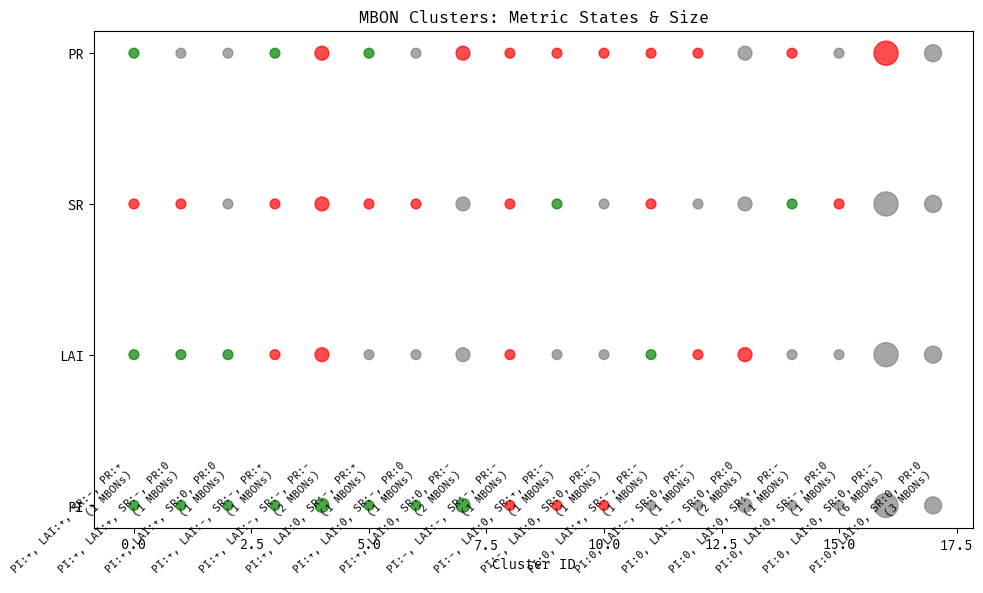

In [43]:
grouped_sorted['Cluster_ID'] = range(len(grouped_sorted))

metrics = ['PI', 'LAI', 'SR', 'PR']
colors = {'+': 'green', '0': 'gray', '-': 'red'}

# Plot
plt.figure(figsize=(10, 6))
for metric in metrics:
    # Extract +/0/- states for each metric
    states = grouped_sorted['Cluster'].str.extract(fr"{metric}:(\+|\-|0)")[0]
    sizes = grouped_sorted['MBON_Count'] * 50  # Scale bubble size
    
    plt.scatter(
        grouped_sorted['Cluster_ID'], 
        [metric]*len(grouped_sorted),
        s=sizes,
        c=states.map(colors),
        alpha=0.7
    )

# Add labels
for i, row in grouped_sorted.iterrows():
    plt.text(row['Cluster_ID'], -0.5, f"{row['Cluster']}\n({row['MBON_Count']} MBONs)", 
             rotation=45, ha='right', fontsize=8)

plt.yticks(range(len(metrics)), metrics)
plt.xlabel("Cluster ID")
plt.title("MBON Clusters: Metric States & Size")
plt.tight_layout()
plt.show()